#### XGBClassifier is an efficient machine learning algorithm provided by the XGBoost library which stands for Extreme Gradient Boosting. It is widely used for solving classification problems like predicting if an email is spam, if a customer will churn or if a transaction is fraudulent. XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.

## Parameters of XGBClassifier
#### n_estimators: Defines the number of boosting rounds. More trees can increase accuracy but also the risk of overfitting and training time.
#### learning_rate: Controls how much each tree contributes to the final prediction. Lower values make the model more robust but require more trees.
#### max_depth: Limits the maximum depth of each decision tree. Deeper trees can capture more patterns but may overfit the data.
#### subsample: Specifies the fraction of training instances to be used for growing each tree. Helps prevent overfitting.
#### colsample_bytree: Fraction of features to be used when building each tree. Reduces correlation between trees and prevents overfitting.
#### gamma: Minimum loss reduction required to make a further partition on a leaf node. Acts as a regularization term to control tree complexity.
#### reg_alpha(L1 regularization) and reg_lambda (L2 regularization): These help prevent overfitting by adding penalties for large weights (coefficients). L1 can lead to sparsity (feature selection), while L2 reduces weight size.
#### objective: Specifies the learning task and the corresponding loss function.
#### scale_pos_weight: Helps with imbalanced classification tasks by giving more importance to the minority class. It’s typically set to the ratio of negative to positive samples.
#### early_stopping_rounds: Used during training with validation data to stop the training process once the evaluation metric stops improving.

## Use cases of XGBClassifier
#### Credit Scoring and Risk Prediction: Banks and financial institutions use XGBClassifier to predict whether a loan applicant is likely to default. Its high accuracy and handling of imbalanced data make it ideal for credit risk modelling.
#### Fraud Detection: In domains like banking and e commerce it helps detect fraudulent transactions by identifying subtle patterns in large, complex datasets.
#### Customer Churn Prediction: Telecom, SaaS and subscription based businesses use it to identify which customers are likely to cancel their service enabling proactive retention strategies.
#### Medical Diagnosis: Used in healthcare for disease classification by analyzing patient data. It can handle missing values and imbalanced datasets often found in medical records.
#### Spam Email Detection: Trains on labelled email data to classify whether incoming emails are spam or not often with better accuracy than traditional models.

#### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

#### Load and see the dataset

In [2]:
df = pd.read_csv('/Users/bhavyakansal/Datasets/Wholesale customers data.csv')
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


#### Explore Statistical Summary of the Data

In [3]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


#### Prepare Features and Target, Split Data

In [4]:
X = df.drop('Channel', axis=1)
y = df['Channel'].map({1:1, 2:0})

#### Now lets split data into test and train

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### Build and Train the XGBoost Model 
#### Here we initialize the XGBoost classifier with specified hyperparameters, train it on the training data and make predictions on the test set.
#### Defines the learning objective, tree depth, learning rate, number of trees and regularization to control overfitting.
#### Fits the XGBoost model on the training data (X_train, y_train).
#### Uses the trained model to predict target labels on the test set (X_test).

In [6]:
parameters = {
    'objective':'binary:logistic',
    'max_depth':4,
    'learning_rate':0.1,
    'n_estimators':100,
    'alpha':10 }

model = XGBClassifier(**parameters)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Evaluate Model Accuracy and Performance

In [7]:
model.score(X_train , y_train)*100 , model.score(X_test , y_test)*100

(93.83116883116884, 90.9090909090909)

In [8]:
y_pred = model.predict(X_test)

#### Plot Confusion Matrix Heatmap

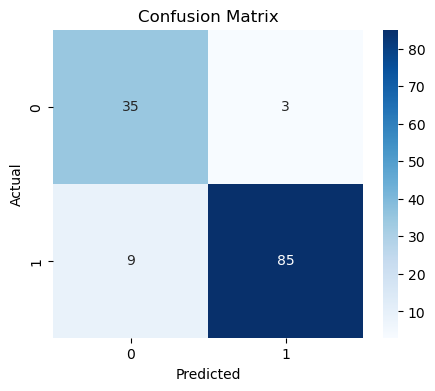

In [9]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Plot Feature Importance

<Figure size 800x600 with 0 Axes>

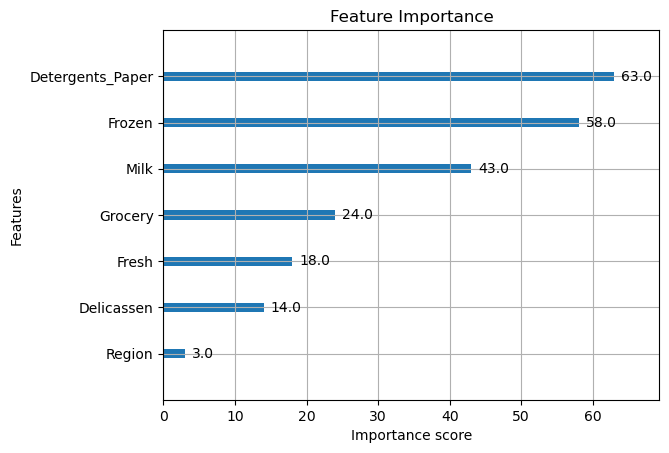

In [10]:
plt.figure(figsize=(8,6))
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()

### Visualize XGBoost Decision Tree
#### Plots one of the trained XGBoost decision trees to help understand how the model makes predictions based on feature splits.

<Figure size 2000x1000 with 0 Axes>

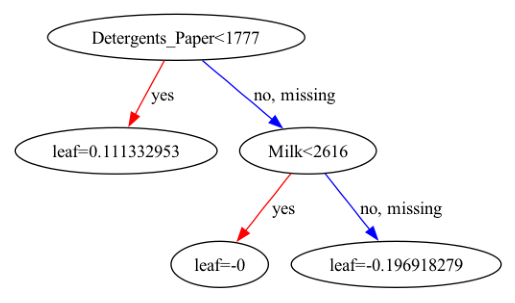

In [13]:
import os
os.environ["PATH"] += os.pathsep + '/opt/homebrew/bin'
plt.figure(figsize=(20,10))
xgb.plot_tree(model, tree_idx=0)
plt.show()